## **1. Import Library**

In [ ]:
import os
import time
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils

print("Semua library berhasil diimport!")
print(f"PyTorch version : {torch.__version__}")

Semua library berhasil diimport!
PyTorch version : 2.10.0+cu128


## **2. Set Device**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device yang digunakan: {device.upper()}")

if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("GPU tidak tersedia, menggunakan CPU. Training akan lebih lambat.")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed(SEED)
print(f"\nRandom seed: {SEED}")

Device yang digunakan: CUDA
   GPU: Tesla T4
   Memory: 15.64 GB

Random seed: 42


## **3. Load Dataset Vision**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive berhasil di-mount!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive berhasil di-mount!


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/[S2] Semester 2/Pembelajaran Mesin/[Generative AI] Tugas Implementasi /[Vision] Implementasi Generative AI/Dataset"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
TEST_PATH  = os.path.join(DATASET_PATH, "test")

CLASSES = sorted(os.listdir(TRAIN_PATH))
print(f"Dataset ditemukan di: {DATASET_PATH}")
print(f"\nKelas yang tersedia ({len(CLASSES)} kelas): {CLASSES}")

total_train = 0
total_test  = 0
print("\nDistribusi Dataset:")
print(f"{'Kelas':<15} {'Train':>8} {'Test':>8}")
print("-" * 35)
for cls in CLASSES:
    n_train = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    n_test  = len(os.listdir(os.path.join(TEST_PATH, cls)))
    total_train += n_train
    total_test  += n_test
    print(f"{cls:<15} {n_train:>8} {n_test:>8}")
print("-" * 35)
print(f"{'TOTAL':<15} {total_train:>8} {total_test:>8}")

Dataset ditemukan di: /content/drive/MyDrive/[S2] Semester 2/Pembelajaran Mesin/[Generative AI] Tugas Implementasi /[Vision] Implementasi Generative AI/Dataset

Kelas yang tersedia (10 kelas): ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Distribusi Dataset:
Kelas              Train     Test
-----------------------------------
airplane            1200      300
automobile          1200      300
bird                1200      300
cat                 1200      300
deer                1200      300
dog                 1200      300
frog                1200      300
horse               1200      300
ship                1200      300
truck               1200      300
-----------------------------------
TOTAL              12000     3000


## **4. Preprocessing Dataset Vision**

In [ ]:
# ─── Hyperparameter ─────────────────────────────────────────
IMAGE_SIZE   = 32      # CIFAR-10 default 32x32
BATCH_SIZE   = 128
LATENT_DIM   = 128     # Dimensi latent space
NUM_EPOCHS   = 5
LEARNING_RATE = 1e-3
NUM_WORKERS  = 2

# Custom Dataset Class
class CIFAR10CustomDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.samples   = []   # list of (filepath, label_idx)
        self.classes   = sorted(os.listdir(root_dir))
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}

        # Kumpulkan semua path gambar
        for cls in self.classes:
            cls_path = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_path):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append(
                        (os.path.join(cls_path, fname), self.class_to_idx[cls])
                    )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert('RGB')   # pastikan 3-channel
        if self.transform:
            image = self.transform(image)
        return image, label


# ─── Transform Pipeline ─────────────────────────────────────
# Normalisasi ke [-1, 1] agar cocok dengan output Tanh di decoder
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),                             # [0,255] → [0,1]
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std =[0.5, 0.5, 0.5])         # [0,1]   → [-1,1]
])

# ─── Buat Dataset & DataLoader ──────────────────────────────
train_dataset = CIFAR10CustomDataset(TRAIN_PATH, transform=transform)
test_dataset  = CIFAR10CustomDataset(TEST_PATH,  transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Dataset berhasil dimuat!")
print(f"Train : {len(train_dataset):,} gambar | {len(train_loader)} batch")
print(f"Test  : {len(test_dataset):,} gambar | {len(test_loader)} batch")
print(f"Kelas : {train_dataset.classes}")
print(f"\nHyperparameter:")
print(f"Image Size   : {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Batch Size   : {BATCH_SIZE}")
print(f"Latent Dim   : {LATENT_DIM}")
print(f"Epochs       : {NUM_EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")

Dataset berhasil dimuat!
Train : 12,000 gambar | 94 batch
Test  : 3,000 gambar | 24 batch
Kelas : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Hyperparameter:
Image Size   : 32x32
Batch Size   : 128
Latent Dim   : 128
Epochs       : 5
Learning Rate: 0.001


In [ ]:
# ─── Visualisasi Sampel Gambar Asli ─────────────────────────
def imshow_grid(images, title="Gambar Asli dari Dataset", nrow=8):
    # Denormalisasi ke [0,1]
    images = images * 0.5 + 0.5
    grid   = vutils.make_grid(images[:nrow*2], nrow=nrow, padding=2)
    npimg  = grid.cpu().numpy().transpose(1, 2, 0)
    npimg  = np.clip(npimg, 0, 1)

    plt.figure(figsize=(16, 4))
    plt.imshow(npimg)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# Ambil satu batch untuk visualisasi
sample_images, sample_labels = next(iter(train_loader))
print(f"Shape satu batch: {sample_images.shape}")
print(f"→ (batch_size={sample_images.shape[0]}, C={sample_images.shape[1]}, H={sample_images.shape[2]}, W={sample_images.shape[3]})")
print(f"Range nilai pixel: [{sample_images.min():.2f}, {sample_images.max():.2f}]")

Shape satu batch: torch.Size([128, 3, 32, 32])
→ (batch_size=128, C=3, H=32, W=32)
Range nilai pixel: [-1.00, 1.00]


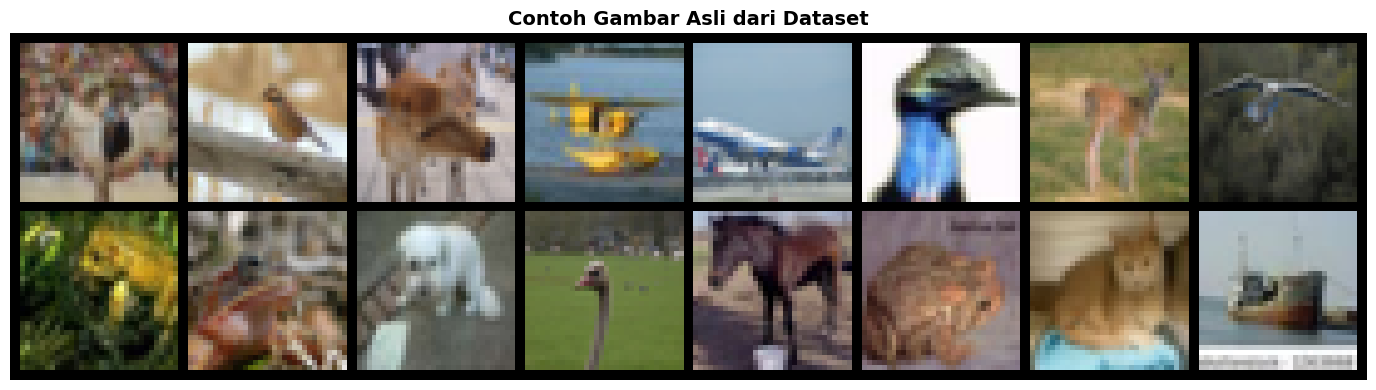

In [ ]:
# Tampilkan gambar asli
imshow_grid(sample_images, title="Contoh Gambar Asli dari Dataset")

In [ ]:
# Label kelas gambar yang ditampilkan
label_names = [train_dataset.classes[l] for l in sample_labels[:16].tolist()]
print(f"\nLabel 16 gambar pertama: {label_names}")


Label 16 gambar pertama: ['horse', 'bird', 'deer', 'airplane', 'airplane', 'bird', 'deer', 'bird', 'frog', 'frog', 'dog', 'bird', 'horse', 'frog', 'cat', 'ship']


## **5. Definisi Model Generatif Vision**

In [ ]:
# ============================================================
# Definisi Model Convolutional Autoencoder
# ============================================================

class Encoder(nn.Module):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        # Menurunkan spatial resolution, menambah channel
        self.conv = nn.Sequential(
            # 3×32×32 → 32×16×16
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            # 32×16×16 → 64×8×8
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            # 64×8×8 → 128×4×4
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        # Flatten: 128×4×4 = 2048 → latent_dim
        self.fc = nn.Linear(128 * 4 * 4, latent_dim)

    def forward(self, x):
        # x: (B, 3, 32, 32)
        h = self.conv(x)            # → (B, 128, 4, 4)
        h = h.view(h.size(0), -1)   # → (B, 2048)   [flatten]
        z = self.fc(h)              # → (B, latent_dim)
        return z                    # z = fθ(x)


class Decoder(nn.Module):
    def __init__(self, latent_dim):
        super(Decoder, self).__init__()
        # Project latent ke spatial feature
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.ReLU(inplace=True)
        )
        # Deconv blocks: menaikkan spatial resolution
        self.deconv = nn.Sequential(
            # 128×4×4 → 64×8×8
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            # 64×8×8 → 32×16×16
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            # 32×16×16 → 3×32×32
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()   # output range [-1, 1], sesuai normalisasi input
        )

    def forward(self, z):
        # z: (B, latent_dim)
        h = self.fc(z)                        # → (B, 2048)
        h = h.view(h.size(0), 128, 4, 4)      # → (B, 128, 4, 4)  [reshape]
        x_hat = self.deconv(h)                # → (B, 3, 32, 32)
        return x_hat                          # x̂ = gϕ(z)


class Autoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder(latent_dim)   # fθ
        self.decoder = Decoder(latent_dim)   # gϕ

    def forward(self, x):
        z     = self.encoder(x)    # encode: x → z
        x_hat = self.decoder(z)    # decode: z → x̂
        return x_hat, z


# ─── Inisialisasi Model ──────────────────────────────────────
ae_model = Autoencoder(latent_dim=LATENT_DIM).to(device)

# ─── Hitung Parameter ────────────────────────────────────────
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Model Autoencoder berhasil dibuat!")
print(f"Total parameter: {count_parameters(ae_model):,}")
print(f"\nArsitektur Autoencoder:")
print(ae_model)

Model Autoencoder berhasil dibuat!
Total parameter: 858,179

Arsitektur Autoencoder:
Autoencoder(
  (encoder): Encoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
      (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2, inplace=True)
      (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (fc): Linear(in_features=2048, out_features=128, bias=True)
  )
  (decoder): Decoder(
    (fc): Sequential(
      (0): Linear(in_features=128, out_features=2048, bias=True)
   

In [ ]:
# ============================================================
# Definisi Model Variational Autoencoder (VAE)
# ============================================================

class VAEEncoder(nn.Module):
    def __init__(self, latent_dim):
        super(VAEEncoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.fc_mu     = nn.Linear(128 * 4 * 4, latent_dim)  # output μ
        self.fc_logvar = nn.Linear(128 * 4 * 4, latent_dim)  # output log σ²

    def forward(self, x):
        h      = self.conv(x)             # → (B, 128, 4, 4)
        h      = h.view(h.size(0), -1)    # → (B, 2048)
        mu     = self.fc_mu(h)            # → (B, latent_dim)  [mean]
        logvar = self.fc_logvar(h)        # → (B, latent_dim)  [log variance]
        return mu, logvar


class VAEDecoder(nn.Module):
    def __init__(self, latent_dim):
        super(VAEDecoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 128 * 4 * 4),
            nn.ReLU(inplace=True)
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(32, 3, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, z):
        h     = self.fc(z)
        h     = h.view(h.size(0), 128, 4, 4)
        x_hat = self.deconv(h)
        return x_hat


class VAE(nn.Module):
    def __init__(self, latent_dim):
        super(VAE, self).__init__()
        self.encoder = VAEEncoder(latent_dim)
        self.decoder = VAEDecoder(latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)    # σ = exp(0.5 × log σ²)
        eps = torch.randn_like(std)      # ε ~ N(0, I)
        z   = mu + std * eps             # z = μ + σ · ε
        return z

    def forward(self, x):
        mu, logvar = self.encoder(x)          # encode: x → μ, log σ²
        z          = self.reparameterize(mu, logvar)  # sample z
        x_hat      = self.decoder(z)          # decode: z → x̂
        return x_hat, mu, logvar

    def generate(self, num_samples, device):
        with torch.no_grad():
            z     = torch.randn(num_samples, LATENT_DIM).to(device)  # sample dari prior
            x_hat = self.decoder(z)                                   # decode ke gambar
        return x_hat


# ─── Loss Function VAE ───────────────────────────────────────
def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    # Reconstruction loss: ||x - x̂||²
    recon_loss = F.mse_loss(x_hat, x, reduction='sum') / x.size(0)

    # KL Divergence: DKL(qϕ(z|x) || p(z))
    # = -0.5 × Σ(1 + log σ² - μ² - exp(log σ²))
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)

    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss


# ─── Inisialisasi Model ──────────────────────────────────────
vae_model = VAE(latent_dim=LATENT_DIM).to(device)

print("Model VAE berhasil dibuat!")
print(f"Total parameter: {count_parameters(vae_model):,}")
print(f"\nArsitektur VAE:")
print(vae_model)

Model VAE berhasil dibuat!
Total parameter: 1,120,451

Arsitektur VAE:
VAE(
  (encoder): VAEEncoder(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
      (3): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): LeakyReLU(negative_slope=0.2, inplace=True)
      (6): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (8): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (fc_mu): Linear(in_features=2048, out_features=128, bias=True)
    (fc_logvar): Linear(in_features=2048, out_features=128, bias=True)
  )
  (decoder): VAEDecoder(
    (fc): Sequential(
      (0):

## **6. Penjelasan Rumus Model Vision**


### Rumus Autoencoder

| Simbol | Keterangan | Kode PyTorch |
|--------|------------|--------------|
| `x` | Gambar input asli | `sample_images` |
| `z = fθ(x)` | Proses encoding, x dikompres ke latent vector | `z = self.encoder(x)` |
| `x̂ = gϕ(z)` | Proses decoding, z direkonstruksi kembali | `x_hat = self.decoder(z)` |
| `L = ‖x − x̂‖²` | Reconstruction loss (MSE) | `nn.MSELoss()(x_hat, x)` |

### Penjelasan
1. **Encoder `fθ`**: Mengkompres gambar 3×32×32 menjadi latent vector berukuran `latent_dim=128`.  
2. **Decoder `gϕ`**: Merekonstruksi gambar dari latent vector kembali ke 3×32×32.  
3. **Reconstruction Loss**: Selisih piksel antara gambar asli `x` dan rekonstruksi `x̂`. Semakin kecil, semakin mirip.

### Rumus VAE

| Simbol | Keterangan | Kode PyTorch |
|--------|------------|--------------|
| `qϕ(z\|x)` | Distribusi posterior latent | `mu, logvar = self.encoder(x)` |
| `μ` | Mean distribusi latent | `mu = self.fc_mu(h)` |
| `σ²` | Variance distribusi latent | `logvar = self.fc_logvar(h)` |
| `ε ~ N(0,I)` | Noise acak standar | `eps = torch.randn_like(std)` |
| `z = μ + σ·ε` | Reparameterization trick | `z = mu + std * eps` |
| `x̂ = gϕ(z)` | Rekonstruksi dari z | `x_hat = self.decoder(z)` |
| `L_KL` | KL Divergence | `-0.5 * sum(1 + logvar - mu² - exp(logvar))` |
| `L_total` | Total VAE loss | `recon_loss + beta * kl_loss` |

### Mengapa Reparameterization Trick?
Sampling `z ~ N(μ, σ²)` tidak dapat dibackprop karena operasi stochastic.  
Solusi: tulis `z = μ + σ·ε` dimana `ε ~ N(0,I)` bukan bagian dari graph → gradien dapat mengalir melalui `μ` dan `σ`.

## **7. Training Model Vision**

In [ ]:
# ============================================================
# Training Autoencoder
# ============================================================

# Optimizer & Loss
ae_optimizer  = optim.Adam(ae_model.parameters(), lr=LEARNING_RATE)
ae_criterion  = nn.MSELoss()          # L = ||x - x̂||²
ae_scheduler  = optim.lr_scheduler.StepLR(ae_optimizer, step_size=5, gamma=0.5)

# Tracking loss per epoch
ae_train_losses = []
ae_test_losses  = []

print("Memulai Training Autoencoder...")
print("=" * 80)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Training Phase ─────────────────────────────────────
    ae_model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        ae_optimizer.zero_grad()

        # Forward pass: x → z → x̂
        x_hat, z = ae_model(images)

        # Hitung reconstruction loss: L = ||x - x̂||²
        loss = ae_criterion(x_hat, images)

        # Backward pass & update weights
        loss.backward()
        ae_optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_train_loss = running_loss / len(train_dataset)
    ae_train_losses.append(epoch_train_loss)

    # ── Evaluation Phase ───────────────────────────────────
    ae_model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            x_hat, _ = ae_model(images)
            loss = ae_criterion(x_hat, images)
            test_loss += loss.item() * images.size(0)

    epoch_test_loss = test_loss / len(test_dataset)
    ae_test_losses.append(epoch_test_loss)

    ae_scheduler.step()

    # ── Print Progress ─────────────────────────────────────
    if epoch % 2 == 0 or epoch == 1:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch:>2}/{NUM_EPOCHS}] "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Test Loss: {epoch_test_loss:.4f} | "
              f"Elapsed: {elapsed:.1f}s")

total_time = time.time() - start_time
print("=" * 80)
print(f"Training Autoencoder selesai!")
print(f"Total waktu training: {total_time:.1f} detik ({total_time/60:.1f} menit)")
print(f"Final Train Loss: {ae_train_losses[-1]:.4f}")
print(f"Final Test Loss : {ae_test_losses[-1]:.4f}")

Memulai Training Autoencoder...
Epoch [ 1/5] Train Loss: 0.1318 | Test Loss: 0.0808 | Elapsed: 43.2s
Epoch [ 2/5] Train Loss: 0.0653 | Test Loss: 0.0559 | Elapsed: 87.6s
Epoch [ 4/5] Train Loss: 0.0443 | Test Loss: 0.0428 | Elapsed: 173.9s
Training Autoencoder selesai!
Total waktu training: 220.3 detik (3.7 menit)
Final Train Loss: 0.0400
Final Test Loss : 0.0384


In [ ]:
# ============================================================
# Training VAE
# ============================================================

# Optimizer & Scheduler
vae_optimizer = optim.Adam(vae_model.parameters(), lr=LEARNING_RATE)
vae_scheduler = optim.lr_scheduler.StepLR(vae_optimizer, step_size=5, gamma=0.5)

# Tracking loss
vae_train_losses = []
vae_test_losses  = []
vae_recon_losses = []
vae_kl_losses    = []

BETA = 1.0  # Bobot KL divergence (beta-VAE)

print("Memulai Training VAE...")
print("=" * 80)

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Training Phase ─────────────────────────────────────
    vae_model.train()
    running_total = 0.0
    running_recon = 0.0
    running_kl    = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        vae_optimizer.zero_grad()

        # Forward: x → μ, log σ² → z → x̂
        x_hat, mu, logvar = vae_model(images)

        # Hitung total loss = L_recon + β × L_KL
        total_loss, recon_loss, kl_loss = vae_loss(x_hat, images, mu, logvar, beta=BETA)

        # Backward & update
        total_loss.backward()
        # Gradient clipping mencegah exploding gradients
        torch.nn.utils.clip_grad_norm_(vae_model.parameters(), max_norm=1.0)
        vae_optimizer.step()

        running_total += total_loss.item() * images.size(0)
        running_recon += recon_loss.item() * images.size(0)
        running_kl    += kl_loss.item()    * images.size(0)

    e_total = running_total / len(train_dataset)
    e_recon = running_recon / len(train_dataset)
    e_kl    = running_kl    / len(train_dataset)
    vae_train_losses.append(e_total)
    vae_recon_losses.append(e_recon)
    vae_kl_losses.append(e_kl)

    # ── Evaluation Phase ───────────────────────────────────
    vae_model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for images, _ in test_loader:
            images = images.to(device)
            x_hat, mu, logvar = vae_model(images)
            t_loss, _, _ = vae_loss(x_hat, images, mu, logvar, beta=BETA)
            test_loss += t_loss.item() * images.size(0)

    e_test = test_loss / len(test_dataset)
    vae_test_losses.append(e_test)

    vae_scheduler.step()

    if epoch % 2 == 0 or epoch == 1:
        elapsed = time.time() - start_time
        print(f"Epoch [{epoch:>2}/{NUM_EPOCHS}] "
              f"Total: {e_total:.4f} | Recon: {e_recon:.4f} | "
              f"KL: {e_kl:.4f} | Test: {e_test:.4f} | {elapsed:.1f}s")

total_time = time.time() - start_time
print("=" * 80)
print(f"Training VAE selesai!")
print(f"Total waktu: {total_time:.1f}s ({total_time/60:.1f} menit)")
print(f"Final Train Loss: {vae_train_losses[-1]:.4f}")
print(f"Final Test Loss : {vae_test_losses[-1]:.4f}")

Memulai Training VAE...
Epoch [ 1/5] Total: 505.4746 | Recon: 455.0492 | KL: 50.4254 | Test: 348.4790 | 48.7s
Epoch [ 2/5] Total: 311.9132 | Recon: 255.5488 | KL: 56.3644 | Test: 283.4876 | 95.9s
Epoch [ 4/5] Total: 251.3860 | Recon: 194.5186 | KL: 56.8675 | Test: 242.3273 | 188.0s
Training VAE selesai!
Total waktu: 232.9s (3.9 menit)
Final Train Loss: 239.8969
Final Test Loss : 234.9921


## **8. Generate Gambar Baru**

In [ ]:
def generate_from_ae(model, num_samples, device):
    model.eval()
    with torch.no_grad():
        # Sample noise dari distribusi normal standar
        z     = torch.randn(num_samples, LATENT_DIM).to(device)
        x_hat = model.decoder(z)   # gϕ(z) → gambar baru
    return x_hat


def reconstruct(model, images, device, is_vae=False):
    model.eval()
    images = images.to(device)
    with torch.no_grad():
        if is_vae:
            x_hat, _, _ = model(images)
        else:
            x_hat, _ = model(images)
    return x_hat


# ─── Ambil gambar test untuk rekonstruksi ────────────────────
test_images, test_labels = next(iter(test_loader))
test_images_subset = test_images[:16]   # ambil 16 gambar

# Rekonstruksi dari AE
ae_recon  = reconstruct(ae_model, test_images_subset, device, is_vae=False)

# Rekonstruksi dari VAE
vae_recon = reconstruct(vae_model, test_images_subset, device, is_vae=True)

# Generate gambar baru dari AE (dari noise)
ae_generated  = generate_from_ae(ae_model, 16, device)

# Generate gambar baru dari VAE (dari prior N(0,I))
vae_generated = vae_model.generate(16, device)

print("Gambar berhasil direkonstruksi dan digenerate!")
print(f"AE Reconstruction  shape: {ae_recon.shape}")
print(f"VAE Reconstruction shape: {vae_recon.shape}")
print(f"AE Generated       shape: {ae_generated.shape}")
print(f"VAE Generated      shape: {vae_generated.shape}")

Gambar berhasil direkonstruksi dan digenerate!
AE Reconstruction  shape: torch.Size([16, 3, 32, 32])
VAE Reconstruction shape: torch.Size([16, 3, 32, 32])
AE Generated       shape: torch.Size([16, 3, 32, 32])
VAE Generated      shape: torch.Size([16, 3, 32, 32])


## **9. Visualisasi Hasil Vision**

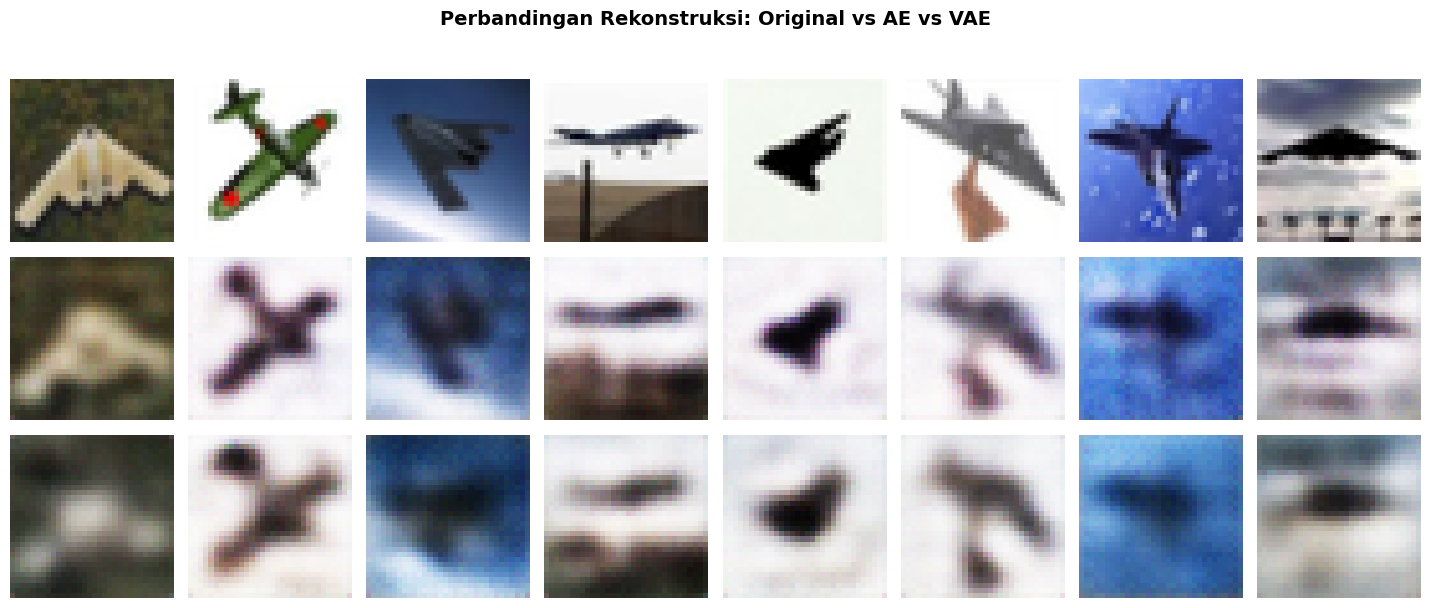

In [ ]:
# ============================================================
# Visualisasi Rekonstruksi
# ============================================================

def denorm(tensor):
    return torch.clamp(tensor * 0.5 + 0.5, 0, 1)


def show_reconstruction_comparison(originals, ae_recons, vae_recons, n=8):
    fig, axes = plt.subplots(3, n, figsize=(n*1.8, 6))
    fig.suptitle('Perbandingan Rekonstruksi: Original vs AE vs VAE',
                 fontsize=14, fontweight='bold', y=1.02)

    row_labels = ['Original', 'AE Recon', 'VAE Recon']
    rows_data  = [
        denorm(originals[:n].cpu()),
        denorm(ae_recons[:n].cpu()),
        denorm(vae_recons[:n].cpu())
    ]

    for row_idx, (label, row_data) in enumerate(zip(row_labels, rows_data)):
        for col_idx in range(n):
            img = row_data[col_idx].permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(label, fontsize=11,
                                                   fontweight='bold', rotation=90,
                                                   labelpad=5)

    plt.tight_layout()
    plt.savefig('reconstruction_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


show_reconstruction_comparison(
    test_images_subset, ae_recon, vae_recon, n=8
)

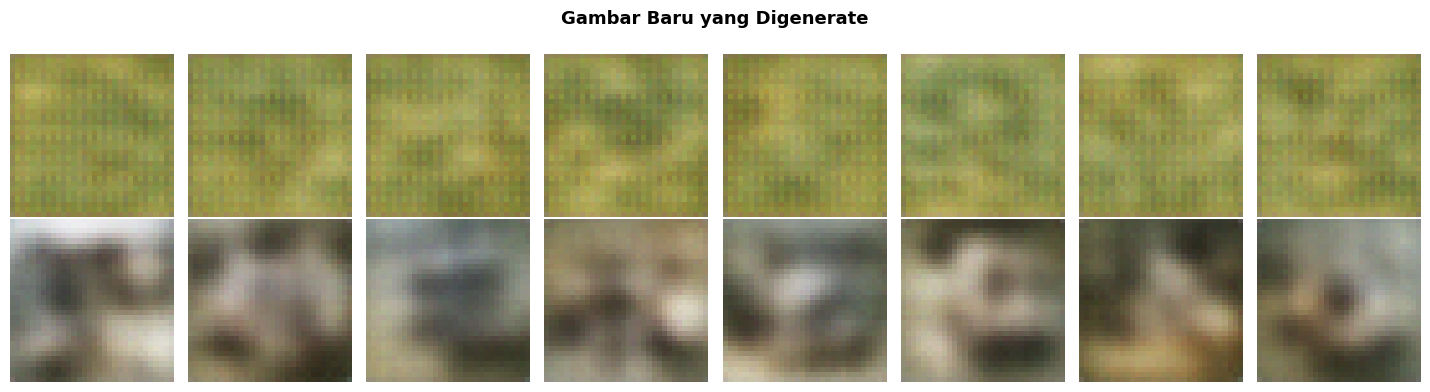

In [ ]:
# ============================================================
# Visualisasi Gambar Generasi Baru
# ============================================================

def show_generated(ae_gen, vae_gen, n=8):
    fig, axes = plt.subplots(2, n, figsize=(n*1.8, 4))
    fig.suptitle('Gambar Baru yang Digenerate',
                 fontsize=13, fontweight='bold')

    for col_idx in range(n):
        for row_idx, (label, gen) in enumerate(
            [('AE Generated', ae_gen), ('VAE Generated', vae_gen)]
        ):
            img = denorm(gen[col_idx].cpu()).permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')
            if col_idx == 0:
                axes[row_idx, col_idx].set_ylabel(label, fontsize=10,
                                                   fontweight='bold')

    plt.tight_layout()
    plt.savefig('generated_images.png', dpi=150, bbox_inches='tight')
    plt.show()


show_generated(ae_generated, vae_generated, n=8)

## **10. Visualisasi Loss**

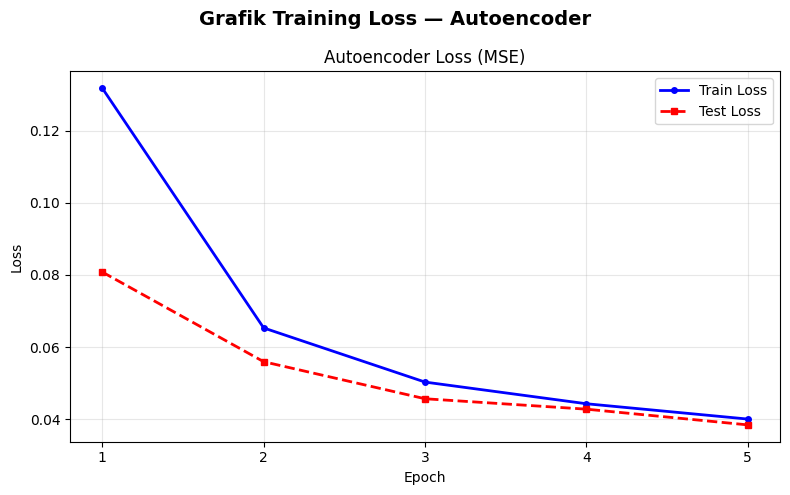

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle('Grafik Training Loss — Autoencoder', fontsize=14, fontweight='bold')

ax.plot(epochs_range, ae_train_losses, 'b-o', markersize=4,
        label='Train Loss', linewidth=2)
ax.plot(epochs_range, ae_test_losses,  'r--s', markersize=4,
        label='Test Loss',  linewidth=2)
ax.set_title('Autoencoder Loss (MSE)', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(epochs_range)

plt.tight_layout()
plt.savefig('ae_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

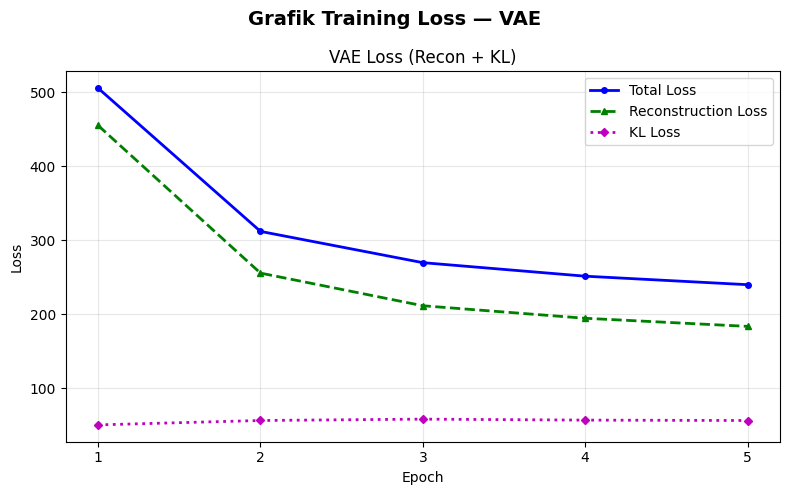

In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
fig.suptitle('Grafik Training Loss — VAE', fontsize=14, fontweight='bold')

ax.plot(epochs_range, vae_train_losses, 'b-o', markersize=4,
        label='Total Loss',          linewidth=2)
ax.plot(epochs_range, vae_recon_losses, 'g--^', markersize=4,
        label='Reconstruction Loss', linewidth=2)
ax.plot(epochs_range, vae_kl_losses,    'm:D',  markersize=4,
        label='KL Loss',             linewidth=2)
ax.set_title('VAE Loss (Recon + KL)', fontsize=12)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(epochs_range)

plt.tight_layout()
plt.savefig('vae_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## **11. Perbandingan Hasil**

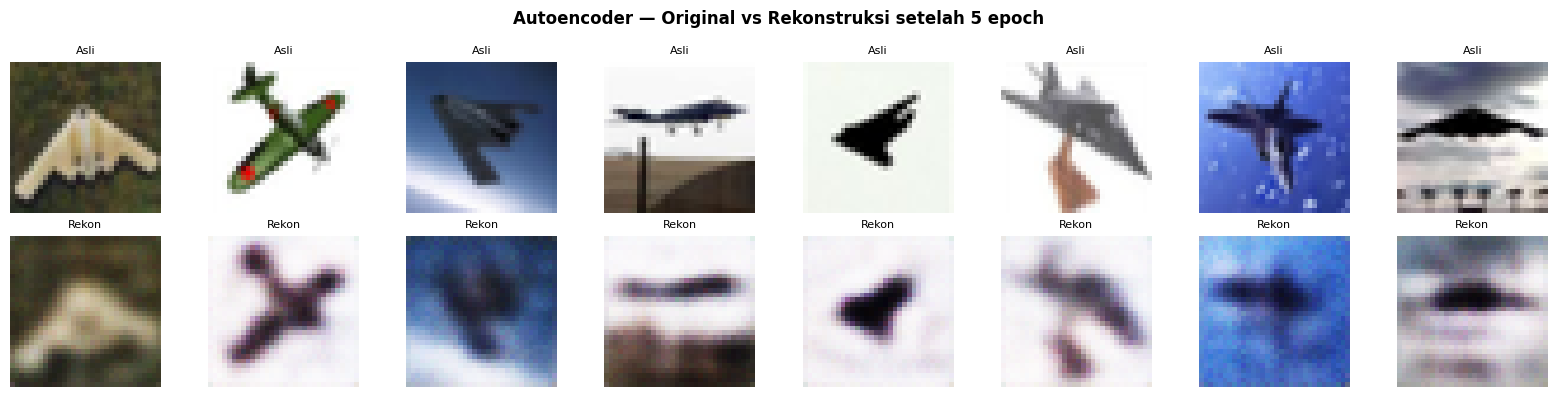

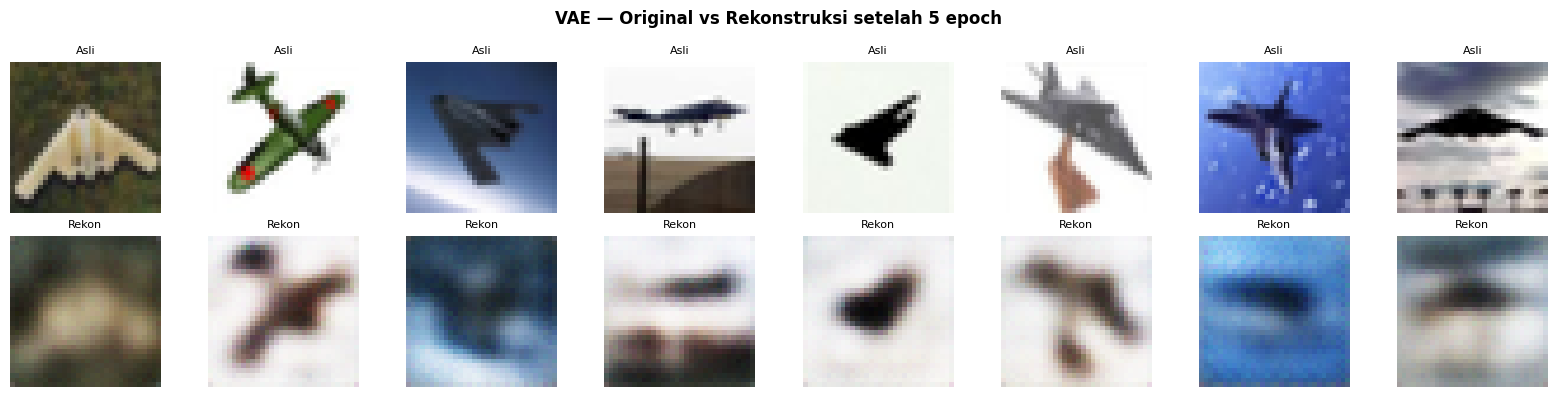

In [ ]:
def show_epoch_progression(model, test_imgs, device, is_vae=False, title="Model"):
    model.eval()
    sample = test_imgs[:8].to(device)
    with torch.no_grad():
        if is_vae:
            recon, _, _ = model(sample)
        else:
            recon, _ = model(sample)

    fig, axes = plt.subplots(2, 8, figsize=(16, 4))
    fig.suptitle(f'{title} — Original vs Rekonstruksi setelah {NUM_EPOCHS} epoch',
                 fontsize=12, fontweight='bold')

    for i in range(8):
        orig = denorm(sample[i].cpu()).permute(1,2,0).numpy()
        rec  = denorm(recon[i].cpu()).permute(1,2,0).numpy()

        axes[0, i].imshow(np.clip(orig, 0, 1))
        axes[0, i].axis('off')
        axes[0, i].set_title('Asli', fontsize=8)

        axes[1, i].imshow(np.clip(rec, 0, 1))
        axes[1, i].axis('off')
        axes[1, i].set_title('Rekon', fontsize=8)

    plt.tight_layout()
    fname = f'{title.lower().replace(" ","_")}_epoch_result.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


show_epoch_progression(ae_model,  test_images, device, is_vae=False, title="Autoencoder")
show_epoch_progression(vae_model, test_images, device, is_vae=True,  title="VAE")

## **12. Eksplorasi Latent Space**

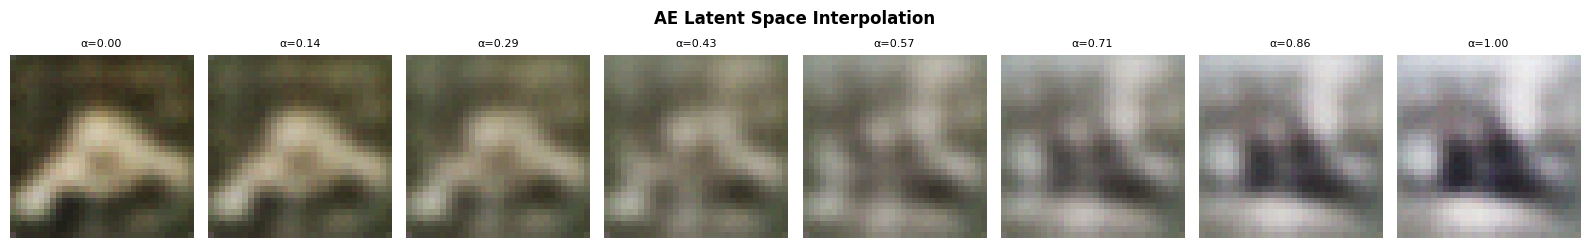

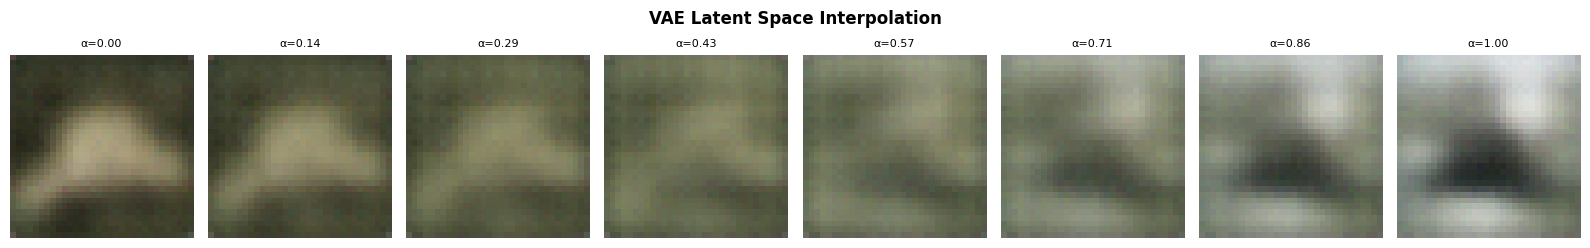

In [ ]:
def explore_latent_interpolation(model, img1, img2, steps=8, device='cpu', is_vae=True):
    model.eval()
    img1 = img1.unsqueeze(0).to(device)
    img2 = img2.unsqueeze(0).to(device)

    with torch.no_grad():
        if is_vae:
            mu1, logvar1 = model.encoder(img1)
            mu2, logvar2 = model.encoder(img2)
            z1, z2 = mu1, mu2  # gunakan mean saja untuk interpolasi
        else:
            z1 = model.encoder(img1)
            z2 = model.encoder(img2)

        # Interpolasi linear: z = (1-α)·z1 + α·z2
        alphas = torch.linspace(0, 1, steps).to(device)
        interp_imgs = []
        for alpha in alphas:
            z_interp = (1 - alpha) * z1 + alpha * z2
            x_hat    = model.decoder(z_interp)
            interp_imgs.append(x_hat)

    # Visualisasi
    fig, axes = plt.subplots(1, steps, figsize=(steps*2, 2.5))
    title = "VAE" if is_vae else "AE"
    fig.suptitle(f'{title} Latent Space Interpolation',
                 fontsize=12, fontweight='bold')

    for i, img_t in enumerate(interp_imgs):
        img_np = denorm(img_t[0].cpu()).permute(1,2,0).numpy()
        axes[i].imshow(np.clip(img_np, 0, 1))
        axes[i].axis('off')
        axes[i].set_title(f'α={alphas[i]:.2f}', fontsize=8)

    plt.tight_layout()
    fname = f'{title.lower()}_interpolation.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()


# Ambil dua gambar berbeda kelas
img1 = test_images[0]   # gambar pertama
img2 = test_images[8]   # gambar berbeda (beda kelas jika mungkin)

explore_latent_interpolation(ae_model,  img1, img2, steps=8, device=device, is_vae=False)
explore_latent_interpolation(vae_model, img1, img2, steps=8, device=device, is_vae=True)

## **13. Eksperimen Variasi Latent Dimension**

In [ ]:
print("Eksperimen: Pengaruh Latent Dimension pada VAE")
print("=" * 55)

latent_dims  = [16, 32, 64, 128]    # variasi dimensi latent
QUICK_EPOCHS = 5                    # epoch singkat untuk perbandingan
exp_results  = {}

for ldim in latent_dims:
    print(f"\n  Training VAE dengan latent_dim = {ldim}...")
    model_tmp = VAE(latent_dim=ldim).to(device)
    opt_tmp   = optim.Adam(model_tmp.parameters(), lr=LEARNING_RATE)

    losses = []
    for epoch in range(1, QUICK_EPOCHS + 1):
        model_tmp.train()
        running = 0.0
        for imgs, _ in train_loader:
            imgs = imgs.to(device)
            opt_tmp.zero_grad()
            xhat, mu, logv = model_tmp(imgs)
            loss, _, _ = vae_loss(xhat, imgs, mu, logv)
            loss.backward()
            opt_tmp.step()
            running += loss.item() * imgs.size(0)
        losses.append(running / len(train_dataset))

    # Evaluasi rekonstruksi pada test set
    model_tmp.eval()
    test_sample = test_images[:8].to(device)
    with torch.no_grad():
        recon, _, _ = model_tmp(test_sample)

    exp_results[ldim] = {'losses': losses, 'recon': recon.cpu()}
    print(f"    → Final Loss: {losses[-1]:.4f}")

print("\nEksperimen selesai!")

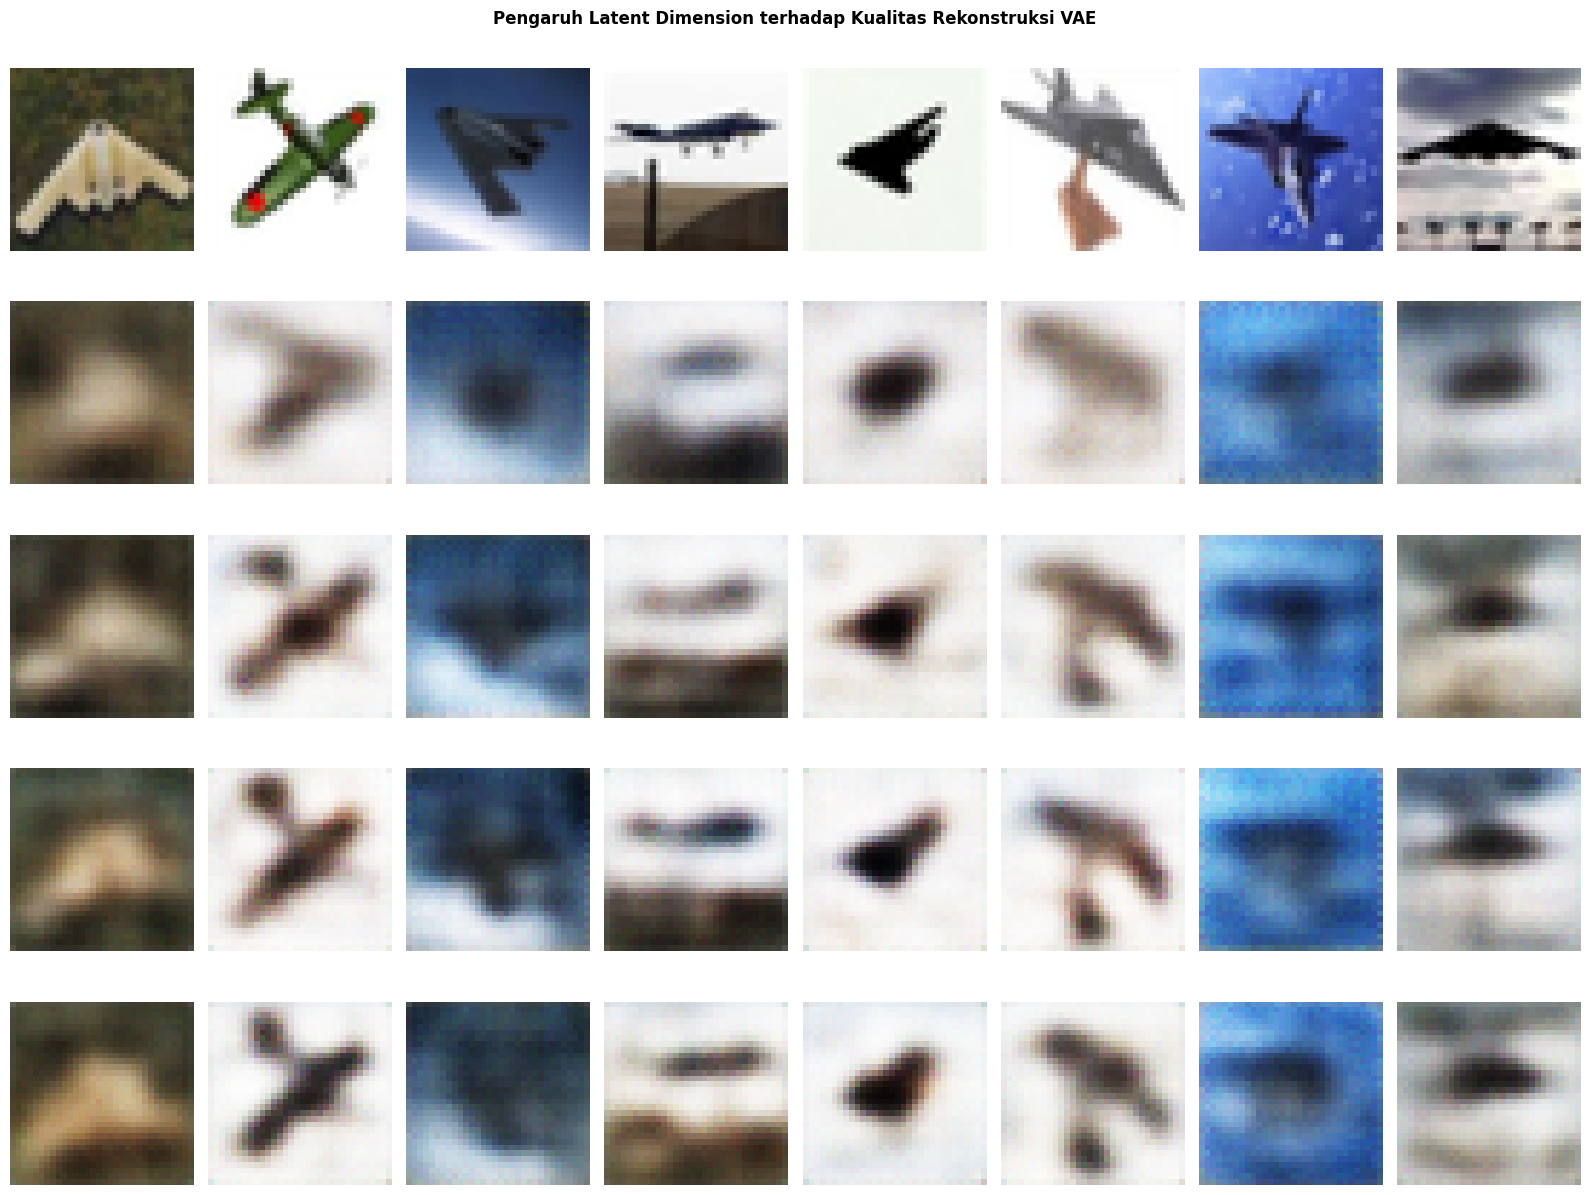

In [ ]:
# ── Visualisasi Hasil Eksperimen ────────────────────────────
fig, axes = plt.subplots(len(latent_dims) + 1, 8, figsize=(16, (len(latent_dims)+1)*2.5))
fig.suptitle('Pengaruh Latent Dimension terhadap Kualitas Rekonstruksi VAE',
             fontsize=12, fontweight='bold')

# Baris pertama: gambar asli
for col in range(8):
    orig = denorm(test_images[col]).permute(1,2,0).numpy()
    axes[0, col].imshow(np.clip(orig, 0, 1))
    axes[0, col].axis('off')
    if col == 0:
        axes[0, col].set_ylabel('Original', fontsize=9, fontweight='bold')

# Baris berikut: rekonstruksi per latent_dim
for row_idx, ldim in enumerate(latent_dims):
    recon = exp_results[ldim]['recon']
    for col in range(8):
        img = denorm(recon[col]).permute(1,2,0).numpy()
        axes[row_idx+1, col].imshow(np.clip(img, 0, 1))
        axes[row_idx+1, col].axis('off')
        if col == 0:
            axes[row_idx+1, col].set_ylabel(f'z_dim={ldim}', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('latent_dim_experiment.png', dpi=150, bbox_inches='tight')
plt.show()

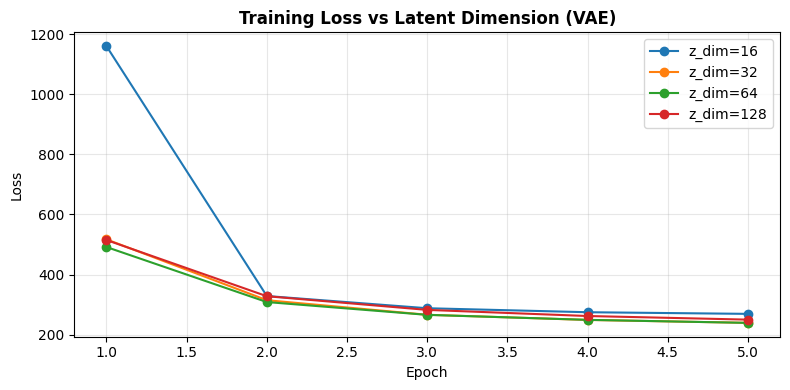

In [ ]:
# ── Plot Loss per Latent Dim ─────────────────────────────────
plt.figure(figsize=(8, 4))
for ldim in latent_dims:
    plt.plot(range(1, QUICK_EPOCHS+1), exp_results[ldim]['losses'],
             marker='o', label=f'z_dim={ldim}')
plt.title('Training Loss vs Latent Dimension (VAE)', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('latent_dim_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## **14. Tabel Perbandingan AE vs VAE**

In [ ]:
comparison_data = {
    'Aspek': [
        'Tipe Output',
        'Latent Space',
        'Loss Function',
        'Reparameterization Trick',
        'Generasi Data Baru',
        'Kualitas Rekonstruksi',
        'Kualitas Generasi Baru',
        'Stabilitas Training',
        'Kemudahan Implementasi',
        'Jumlah Parameter',
        'Final Train Loss',
    ],
    'Autoencoder (AE)': [
        'Rekonstruksi deterministik',
        'Tidak terstruktur, tidak kontinu',
        'MSE: ||x - x̂||²',
        'Tidak ada',
        'Buruk (latent space tidak teratur)',
        'Lebih tajam',
        'Kurang variatif, artefak tinggi',
        'Sangat stabil',
        'Mudah',
        f'{count_parameters(ae_model):,}',
        f'{ae_train_losses[-1]:.4f}',
    ],
    'Variational AE (VAE)': [
        'Rekonstruksi + Generasi baru',
        'Terstruktur, kontinu ~ N(0,I)',
        'MSE + β×KL Divergence',
        'Ada (z = μ + σ·ε)',
        'Bagus (sampling dari prior p(z))',
        'Sedikit blur (trade-off dengan KL)',
        'Lebih variatif & smooth',
        'Stabil',
        'Sedikit lebih kompleks',
        f'{count_parameters(vae_model):,}',
        f'{vae_train_losses[-1]:.4f}',
    ]
}

df_comparison = pd.DataFrame(comparison_data)
print("Tabel Perbandingan Autoencoder vs VAE")
df_comparison

Tabel Perbandingan Autoencoder vs VAE


,Aspek,Autoencoder (AE),Variational AE (VAE)
0,Tipe Output,Rekonstruksi deterministik,Rekonstruksi + Generasi baru
1,Latent Space,"Tidak terstruktur, tidak kontinu","Terstruktur, kontinu ~ N(0,I)"
2,Loss Function,MSE: ||x - x̂||²,MSE + β×KL Divergence
3,Reparameterization Trick,Tidak ada,Ada (z = μ + σ·ε)
4,Generasi Data Baru,Buruk (latent space tidak teratur),Bagus (sampling dari prior p(z))
5,Kualitas Rekonstruksi,Lebih tajam,Sedikit blur (trade-off dengan KL)
6,Kualitas Generasi Baru,"Kurang variatif, artefak tinggi",Lebih variatif & smooth
7,Stabilitas Training,Sangat stabil,Stabil
8,Kemudahan Implementasi,Mudah,Sedikit lebih kompleks
9,Jumlah Parameter,"858,179","1,120,451"


In [ ]:
# ─── Tabel Hubungan Rumus dengan Kode PyTorch ────────────────

mapping_data = {
    'Konsep': [
        'Encoder AE',
        'Decoder AE',
        'Reconstruction Loss',
        'VAE Encoder (distribusi)',
        'Reparameterization',
        'KL Divergence Loss',
        'Total VAE Loss',
        'Generate (AE)',
        'Generate (VAE)',
    ],
    'Rumus': [
        'z = fθ(x)',
        'x̂ = gϕ(z)',
        'L = ||x - x̂||²',
        'qϕ(z|x) → μ, log σ²',
        'z = μ + σ·ε, ε~N(0,I)',
        'DKL(qϕ(z|x) || p(z))',
        'L = L_recon + β·L_KL',
        'z~N(0,1) → gϕ(z)',
        'z~p(z)=N(0,I) → gϕ(z)',
    ],
    'Kode PyTorch': [
        'z = self.encoder(x)',
        'x_hat = self.decoder(z)',
        'nn.MSELoss()(x_hat, x)',
        'mu, logvar = self.encoder(x)',
        'z = mu + std * eps',
        '-0.5 * sum(1 + logvar - mu² - exp(logvar))',
        'recon_loss + beta * kl_loss',
        'z=torch.randn(n,LATENT_DIM); decoder(z)',
        'z=torch.randn(n,LATENT_DIM); decoder(z)',
    ]
}

df_mapping = pd.DataFrame(mapping_data)
print("\nTabel Hubungan Rumus dengan Kode PyTorch")
df_mapping


Tabel Hubungan Rumus dengan Kode PyTorch


,Konsep,Rumus,Kode PyTorch
0,Encoder AE,z = fθ(x),z = self.encoder(x)
1,Decoder AE,x̂ = gϕ(z),x_hat = self.decoder(z)
2,Reconstruction Loss,L = ||x - x̂||²,"nn.MSELoss()(x_hat, x)"
3,VAE Encoder (distribusi),"qϕ(z|x) → μ, log σ²","mu, logvar = self.encoder(x)"
4,Reparameterization,"z = μ + σ·ε, ε~N(0,I)",z = mu + std * eps
5,KL Divergence Loss,DKL(qϕ(z|x) || p(z)),-0.5 * sum(1 + logvar - mu² - exp(logvar))
6,Total VAE Loss,L = L_recon + β·L_KL,recon_loss + beta * kl_loss
7,Generate (AE),"z~N(0,1) → gϕ(z)","z=torch.randn(n,LATENT_DIM); decoder(z)"
8,Generate (VAE),"z~p(z)=N(0,I) → gϕ(z)","z=torch.randn(n,LATENT_DIM); decoder(z)"


## **15. Analisis Hitung MSE & PSNR per Model**

In [ ]:
def compute_metrics(model, loader, device, is_vae=False, n_batches=5):
    model.eval()
    total_mse  = 0.0
    total_psnr = 0.0
    count      = 0

    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= n_batches:
                break
            images = images.to(device)
            if is_vae:
                x_hat, _, _ = model(images)
            else:
                x_hat, _ = model(images)

            # MSE dalam range [-1, 1]
            mse = F.mse_loss(x_hat, images).item()
            # PSNR = 10 × log10(MAX² / MSE), MAX=2 untuk range [-1,1]
            psnr = 10 * math.log10(4.0 / (mse + 1e-10))
            total_mse  += mse
            total_psnr += psnr
            count += 1

    return total_mse/count, total_psnr/count


ae_mse,  ae_psnr  = compute_metrics(ae_model,  test_loader, device, is_vae=False)
vae_mse, vae_psnr = compute_metrics(vae_model, test_loader, device, is_vae=True)

print("Metrik Kualitas Rekonstruksi pada Test Set")
print("=" * 50)
print(f"{'Model':<20} {'MSE':>10} {'PSNR (dB)':>12}")
print("-" * 50)
print(f"{'Autoencoder':<20} {ae_mse:>10.4f} {ae_psnr:>12.2f}")
print(f"{'VAE':<20} {vae_mse:>10.4f} {vae_psnr:>12.2f}")
print("=" * 50)
print("\nCatatan: PSNR lebih tinggi = rekonstruksi lebih mirip aslinya")
print("         VAE cenderung lebih blur → PSNR bisa lebih rendah dari AE,")
print("         namun VAE unggul dalam generasi gambar BARU yang variatif.")

## **16. Pertanyaan Analisis Wajib**

**1. Apa perbedaan model generatif dan model klasifikasi?**  
Model klasifikasi memetakan `input → label` (diskriminatif). Model generatif mempelajari distribusi `p(x)` atau `p(x|c)` untuk menghasilkan data baru yang realistis.


**2. Model vision generatif apa yang digunakan?**  
Autoencoder (AE) dan Variational Autoencoder (VAE) pada dataset CIFAR-10 custom (32×32, 10 kelas).

**3. Rumus utama apa yang digunakan?**  
- AE: `z=fθ(x)`, `x̂=gϕ(z)`, `L=||x-x̂||²`  
- VAE: `z=μ+σ·ε`, `L=L_recon + β·DKL(qϕ(z|x)||p(z))`


**4. Bagaimana model menghasilkan gambar baru?**  
Dengan menyample `z ~ N(0,I)` dari prior, kemudian melewatkannya ke decoder `gϕ(z)` → gambar baru.


**5. Apa fungsi latent vector?**  
Kompresi representasi fitur gambar ke dimensi kecil. Memanipulasi `z` → menghasilkan variasi gambar baru.


**6. Apakah hasil gambar menyerupai data asli?**  
Rekonstruksi AE lebih tajam namun generasi kurang variatif. VAE rekonstruksinya sedikit blur (trade-off KL), tetapi generasi baru lebih smooth dan beragam.


**7. Apa kesulitan training model generatif?**  
Menyeimbangkan reconstruction loss dan KL divergence pada VAE (beta tuning). Latent space harus terstruktur agar generasi bermakna.

**8. Apakah loss kecil selalu berarti output generasi bagus?**  
Tidak. Loss kecil hanya berarti rekonstruksi bagus, namun kualitas generasi bergantung pada struktur latent space, bukan hanya nilai loss.